# Chương 4. HỌC SÂU

## Mô hình AlexNet

Kiến trúc AlexNet, do Alex Krizhevsky và cộng sự giới thiệu năm 2012 trong bài “ImageNet Classification with Deep Convolutional Neural Networks”, đã giành chiến thắng tại cuộc thi ILSVRC.

<p align="center">
  <img src="./picture/AlexNet Architecture.png" width="800">
  <br>
  <em>Hình 1. Kiến trúc AlexNet được đề xuất trong ImageNet Classification with Deep Convolutional Neural Networks.</em>
</p>


In [8]:
# Kiểm tra đã nhận Cuda
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 1


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input

# Local Response Normalization (LRN)
def LRN(x):
    return tf.nn.local_response_normalization(
        x, depth_radius=2, bias=1.0, alpha=1e-4, beta=0.75
    )

def group_conv(x, filters, kernel):
    x1, x2 = tf.split(x, 2, axis=3)
    y1 = layers.Conv2D(filters, kernel, padding='same', activation='relu')(x1)
    y2 = layers.Conv2D(filters, kernel, padding='same', activation='relu')(x2)
    return layers.Concatenate(axis=3)([y1, y2])

def alexnet():
    inp = Input(shape=(227, 227, 3))

    # Conv1
    x = layers.Conv2D(96, (11, 11), strides=4, activation='relu')(inp)
    x = layers.Lambda(LRN)(x)
    x = layers.MaxPooling2D(3, strides=2)(x)

    # Conv2 (group=2)
    x = group_conv(x, 128, (5, 5))
    x = layers.Lambda(LRN)(x)
    x = layers.MaxPooling2D(3, strides=2)(x)

    # Conv3
    x = layers.Conv2D(384, (3, 3), padding='same', activation='relu')(x)

    # Conv4 (group=2)
    x = group_conv(x, 192, (3, 3))

    # Conv5 (group=2)
    x = group_conv(x, 128, (3, 3))
    x = layers.MaxPooling2D(3, strides=2)(x)

    # Fully Connected 
    x = layers.Flatten()(x)
    x = layers.Dense(4096, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(4096, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(1000, activation='softmax')(x)

    return models.Model(inputs=inp, outputs=out)

model = alexnet()
model.summary()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 227, 227, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_13 (Conv2D)             (None, 55, 55, 96)   34944       ['input_2[0][0]']                
                                                                                                  
 lambda_5 (Lambda)              (None, 55, 55, 96)   0           ['conv2d_13[0][0]']              
                                                                                                  
 max_pooling2d_6 (MaxPooling2D)  (None, 27, 27, 96)  0           ['lambda_5[0][0]']         

## Ứng dụng trên dữ liệu thực tế

### Download dữ liệu
Bộ dữ liệu “Cat and Dog” do người dùng tongpython cung cấp trên Kaggle là một tập dữ liệu quen thuộc trong các bài toán học sâu cơ bản, dùng để xây dựng các mô hình phân loại hình ảnh giữa mèo (cat) và chó (dog).

Link truy cập: https://www.kaggle.com/datasets/tongpython/cat-and-dog


In [ ]:
import os
os.environ["KAGGLEHUB_CACHE"] = r"C:\Users\Admin\Desktop\my_ai_book\data"

import kagglehub

# Download dataset
path = kagglehub.dataset_download("cat-and-dog")
print("Path to dataset files:", path)

# Liệt kê file bên trong thư mục
print("\n📂 Files inside the dataset folder:")
print(os.listdir(path))

c:\Users\Admin\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 218M/218M [03:22<00:00, 1.13MB/s] 

Extracting files...


Path to dataset files: C:\Users\Admin\Desktop\my_ai_book\data\datasets\tongpython\cat-and-dog\versions\1

📂 Files inside the dataset folder:
['test_set', 'training_set']


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

train_dir = r"C:/Users/Admin/Desktop/my_ai_book/data/datasets/cat-and-dog/training_set"
test_dir  = r"C:/Users/Admin/Desktop/my_ai_book/data/datasets/cat-and-dog/test_set"

IMG_SIZE = (224, 224)
BATCH    = 32
SEED     = 1
AUTOTUNE = tf.data.AUTOTUNE

# Nếu thư mục là cats/dogs đúng chuẩn thì không cần class_names
# Ở đây ép cho chắc chắn theo tên thư mục phổ biến
CLASS_NAMES = ["cats", "dogs"] #Cats: 0, dogs: 1

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode="binary",
    shuffle=True,
    seed=SEED,
    class_names=CLASS_NAMES
)
# lấy 20% train làm validation
val_size = int(0.2 * len(train_ds))
val_ds   = train_ds.take(val_size)
train_ds = train_ds.skip(val_size)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode="binary", # dựa trên vị trí của thư mục nhãn (class)
    shuffle=False,
    class_names=CLASS_NAMES
)

def configure(ds, training=False):
    if training:
        ds = ds.shuffle(1000, seed=SEED, reshuffle_each_iteration=True)
    return ds.prefetch(AUTOTUNE)

train_ds = configure(train_ds, training=True)
val_ds   = configure(val_ds)
test_ds  = configure(test_ds)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


In [66]:
train_ds

<PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

C:\Users\Admin\AppData\Local\Temp\ipykernel_14728\1177901505.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lbl = int(labels[i].numpy())


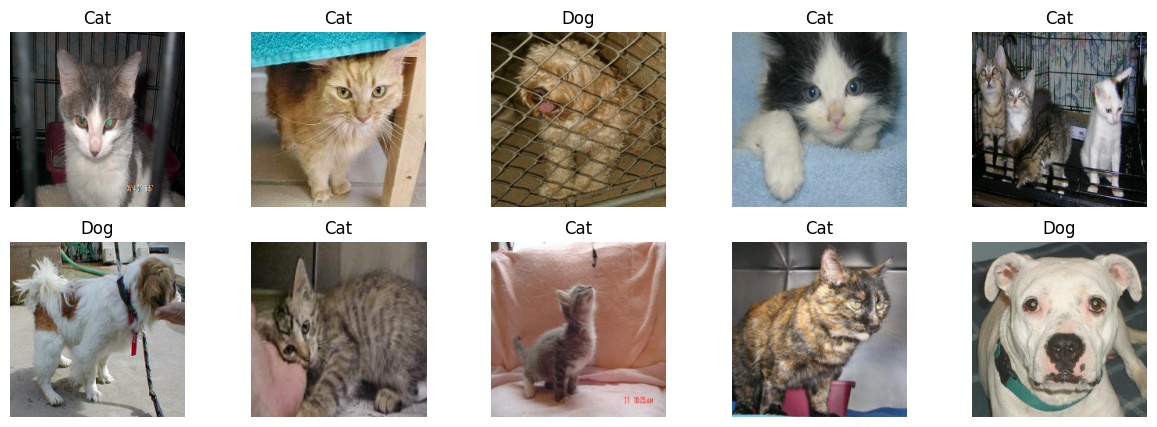

In [ ]:
import matplotlib.pyplot as plt

# Lấy 1 batch đầu tiên
images, labels = next(iter(train_ds))

plt.figure(figsize=(15, 5))

for i in range(10):  # in 8 ảnh đầu tiên
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    lbl = int(labels[i].numpy())
    plt.title("Cat" if lbl == 0 else "Dog")
    plt.axis("off")
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input

# Local Response Normalization (LRN)
def LRN(x):
    return tf.nn.local_response_normalization(
        x, depth_radius=2, bias=1.0, alpha=1e-4, beta=0.75
    )

# Grouped Convolution
def group_conv(x, filters, kernel):
    x1, x2 = tf.split(x, 2, axis=3)
    y1 = layers.Conv2D(filters, kernel, padding='same', activation='relu')(x1)
    y2 = layers.Conv2D(filters, kernel, padding='same', activation='relu')(x2)
    return layers.Concatenate(axis=3)([y1, y2])

# Adjusted AlexNet for binary classification
def alexnet_binary():
    inp = Input(shape=(224, 224, 3))

    # Conv1
    x = layers.Conv2D(96, (11, 11), strides=4, activation='relu')(inp)
    x = layers.Lambda(LRN)(x)
    x = layers.MaxPooling2D(3, strides=2)(x)

    # Conv2 (group=2)
    x = group_conv(x, 128, (5, 5))
    x = layers.Lambda(LRN)(x)
    x = layers.MaxPooling2D(3, strides=2)(x)

    # Conv3
    x = layers.Conv2D(384, (3, 3), padding='same', activation='relu')(x)

    # Conv4 (group=2)
    x = group_conv(x, 192, (3, 3))

    # Conv5 (group=2)
    x = group_conv(x, 128, (3, 3))
    x = layers.MaxPooling2D(3, strides=2)(x)

    # Fully Connected 
    x = layers.Flatten()(x)
    x = layers.Dense(4096, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(4096, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    # Binary output
    out = layers.Dense(1, activation='sigmoid')(x)

    return models.Model(inputs=inp, outputs=out)

model = alexnet_binary()
model.summary()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_8 (Conv2D)              (None, 54, 54, 96)   34944       ['input_2[0][0]']                
                                                                                                  
 lambda_2 (Lambda)              (None, 54, 54, 96)   0           ['conv2d_8[0][0]']               
                                                                                                  
 max_pooling2d_3 (MaxPooling2D)  (None, 26, 26, 96)  0           ['lambda_2[0][0]']         

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [69]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20


201/201 [==============================] - 35s 81ms/step - loss: 0.9522 - accuracy: 0.5343 - val_loss: 0.6587 - val_accuracy: 0.6531
Epoch 2/20
201/201 [==============================] - 22s 98ms/step - loss: 0.6666 - accuracy: 0.5916 - val_loss: 0.6442 - val_accuracy: 0.6256
Epoch 3/20
201/201 [==============================] - 21s 98ms/step - loss: 0.6491 - accuracy: 0.6148 - val_loss: 0.6530 - val_accuracy: 0.6275
Epoch 4/20
201/201 [==============================] - 23s 106ms/step - loss: 0.5999 - accuracy: 0.6731 - val_loss: 0.7537 - val_accuracy: 0.6025
Epoch 5/20
201/201 [==============================] - 21s 94ms/step - loss: 0.5633 - accuracy: 0.7094 - val_loss: 0.5390 - val_accuracy: 0.7294
Epoch 6/20
201/201 [==============================] - 21s 95ms/step - loss: 0.5168 - accuracy: 0.7408 - val_loss: 0.5468 - val_accuracy: 0.7431
Epoch 7/20
201/201 [==============================] - 22s 103ms/step - loss: 0.5209 - accuracy: 0.7410 - val_loss: 0.5053 - val_accuracy: 0.7581
E

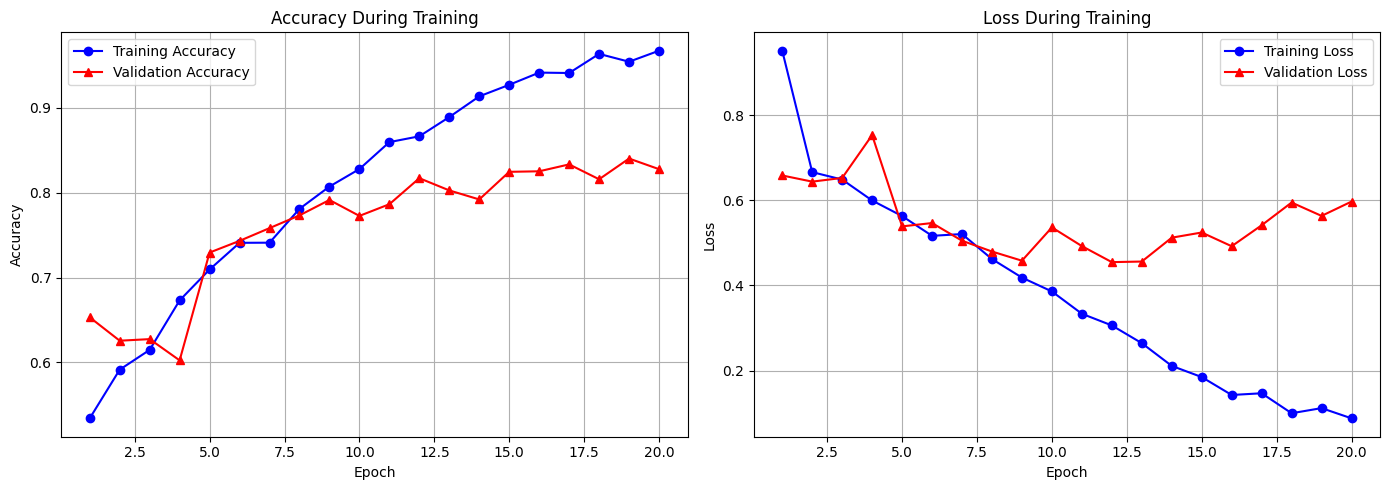

In [71]:
import matplotlib.pyplot as plt

# Lấy dữ liệu training từ lịch sử
acc      = history.history["accuracy"]
val_acc  = history.history["val_accuracy"]
loss     = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# ---- Accuracy ----
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, "bo-", label="Training Accuracy")
plt.plot(epochs, val_acc, "r^-", label="Validation Accuracy")
plt.title("Accuracy During Training")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# ---- Loss ----
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, "bo-", label="Training Loss")
plt.plot(epochs, val_loss, "r^-", label="Validation Loss")
plt.title("Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [70]:
model.save("alexnet_catdog.h5")